# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Load the Data

In [3]:
train = pd.read_csv("Training.csv")
test = pd.read_csv("Testing.csv")

print("Training shape:", train.shape)
print("Testing shape:", test.shape)

Training shape: (4920, 134)
Testing shape: (42, 133)


In [33]:
print("Extra column in training:", set(train.columns) - set(test.columns))
train = train.drop(columns=['Unnamed: 133'], errors='ignore')

print("Training shape after fix:", train.shape)
print("Testing shape:", test.shape)

Extra column in training: set()
Training shape after fix: (4920, 133)
Testing shape: (42, 133)


In [13]:
print("First 5 rows of Training data:")
train.head()

First 5 rows of Training data:


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [7]:
print("Null values in Training:", train.isnull().sum().sum())
print("Null values in Testing:", test.isnull().sum().sum())
print("\nNumber of disease classes:", train['prognosis'].nunique())
print("\nDisease classes:\n", train['prognosis'].unique())

Null values in Training: 0
Null values in Testing: 0

Number of disease classes: 41

Disease classes:
 ['Fungal infection' 'Allergy' 'GERD' 'Chronic cholestasis' 'Drug Reaction'
 'Peptic ulcer diseae' 'AIDS' 'Diabetes ' 'Gastroenteritis'
 'Bronchial Asthma' 'Hypertension ' 'Migraine' 'Cervical spondylosis'
 'Paralysis (brain hemorrhage)' 'Jaundice' 'Malaria' 'Chicken pox'
 'Dengue' 'Typhoid' 'hepatitis A' 'Hepatitis B' 'Hepatitis C'
 'Hepatitis D' 'Hepatitis E' 'Alcoholic hepatitis' 'Tuberculosis'
 'Common Cold' 'Pneumonia' 'Dimorphic hemmorhoids(piles)' 'Heart attack'
 'Varicose veins' 'Hypothyroidism' 'Hyperthyroidism' 'Hypoglycemia'
 'Osteoarthristis' 'Arthritis' '(vertigo) Paroymsal  Positional Vertigo'
 'Acne' 'Urinary tract infection' 'Psoriasis' 'Impetigo']


# Encode the Target Label

In [9]:
le = LabelEncoder()

X_train = train.drop('prognosis', axis=1)
y_train = le.fit_transform(train['prognosis'])

X_test = test.drop('prognosis', axis=1)
y_test = le.transform(test['prognosis'])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Sample encoded labels:", y_train[:5])

X_train shape: (4920, 132)
X_test shape: (42, 132)
Sample encoded labels: [15 15 15 15 15]


# EDA: Disease Class Distribution

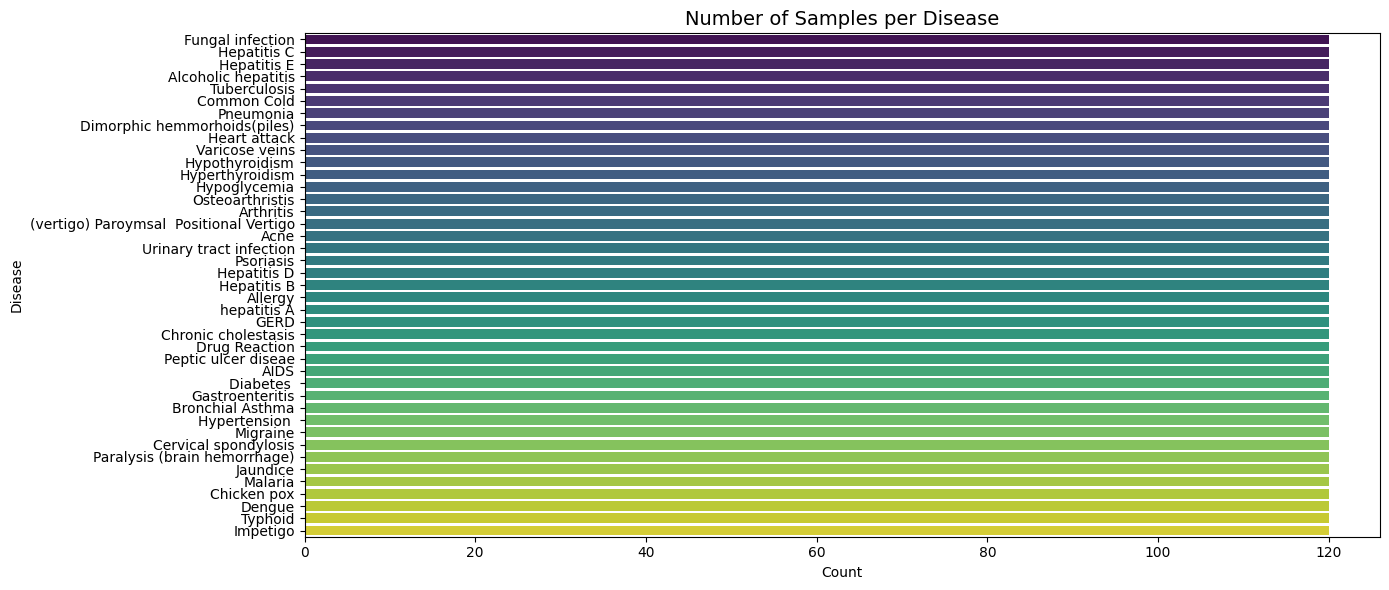

In [11]:
plt.figure(figsize=(14, 6))
disease_counts = train['prognosis'].value_counts()
sns.barplot(x=disease_counts.values, y=disease_counts.index, palette='viridis')
plt.title('Number of Samples per Disease', fontsize=14)
plt.xlabel('Count')
plt.ylabel('Disease')
plt.tight_layout()
plt.show()

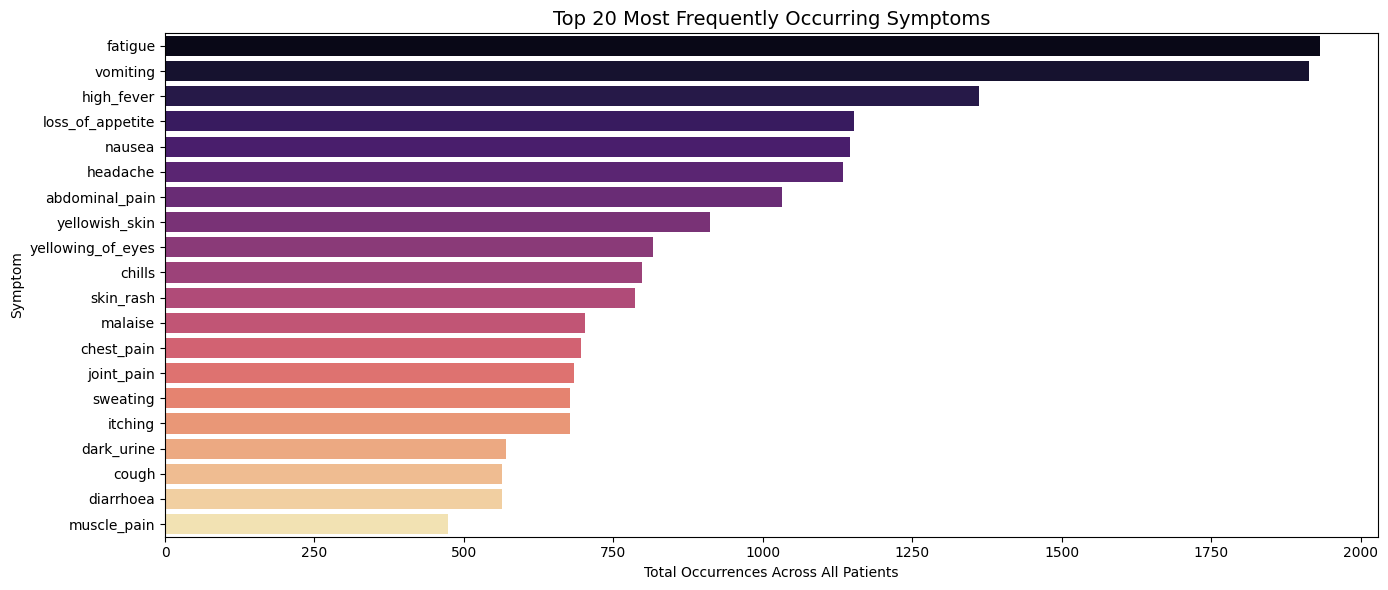

In [15]:
symptom_counts = X_train.sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(14, 6))
sns.barplot(x=symptom_counts.values, y=symptom_counts.index, palette='magma')
plt.title('Top 20 Most Frequently Occurring Symptoms', fontsize=14)
plt.xlabel('Total Occurrences Across All Patients')
plt.ylabel('Symptom')
plt.tight_layout()
plt.show()

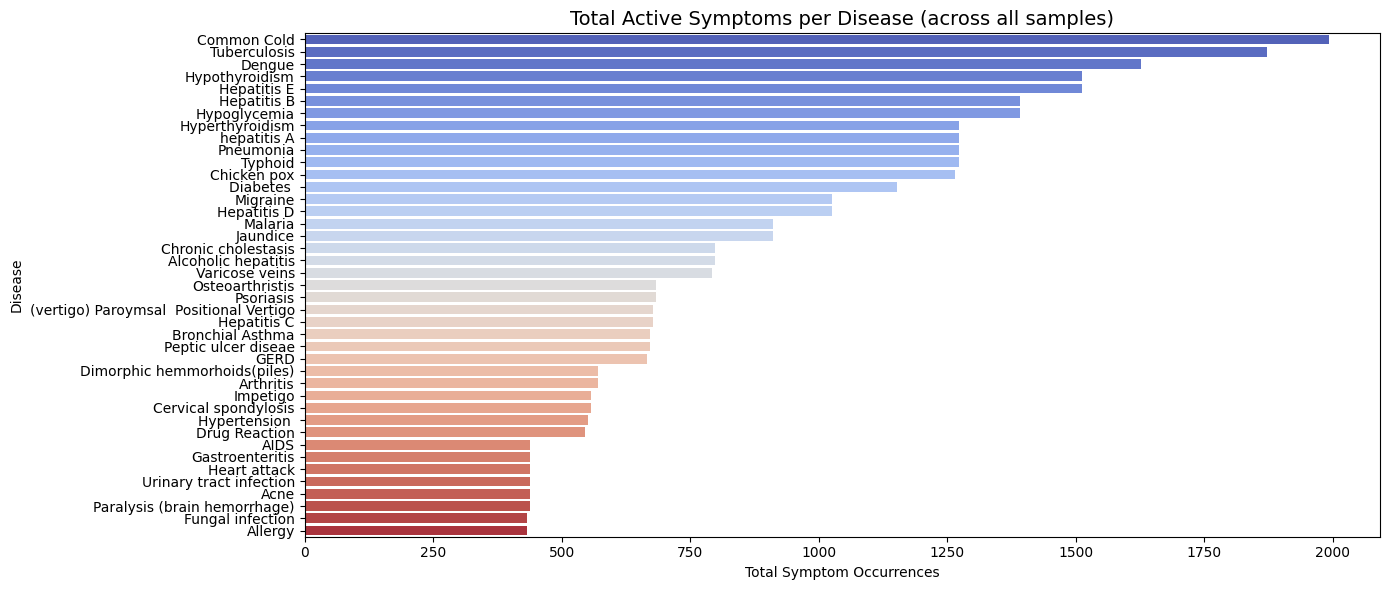

In [17]:
train_copy = train.copy()
symptom_cols = X_train.columns.tolist()

avg_symptoms = train_copy.groupby('prognosis')[symptom_cols].sum().sum(axis=1).sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=avg_symptoms.values, y=avg_symptoms.index, palette='coolwarm')
plt.title('Total Active Symptoms per Disease (across all samples)', fontsize=14)
plt.xlabel('Total Symptom Occurrences')
plt.ylabel('Disease')
plt.tight_layout()
plt.show()

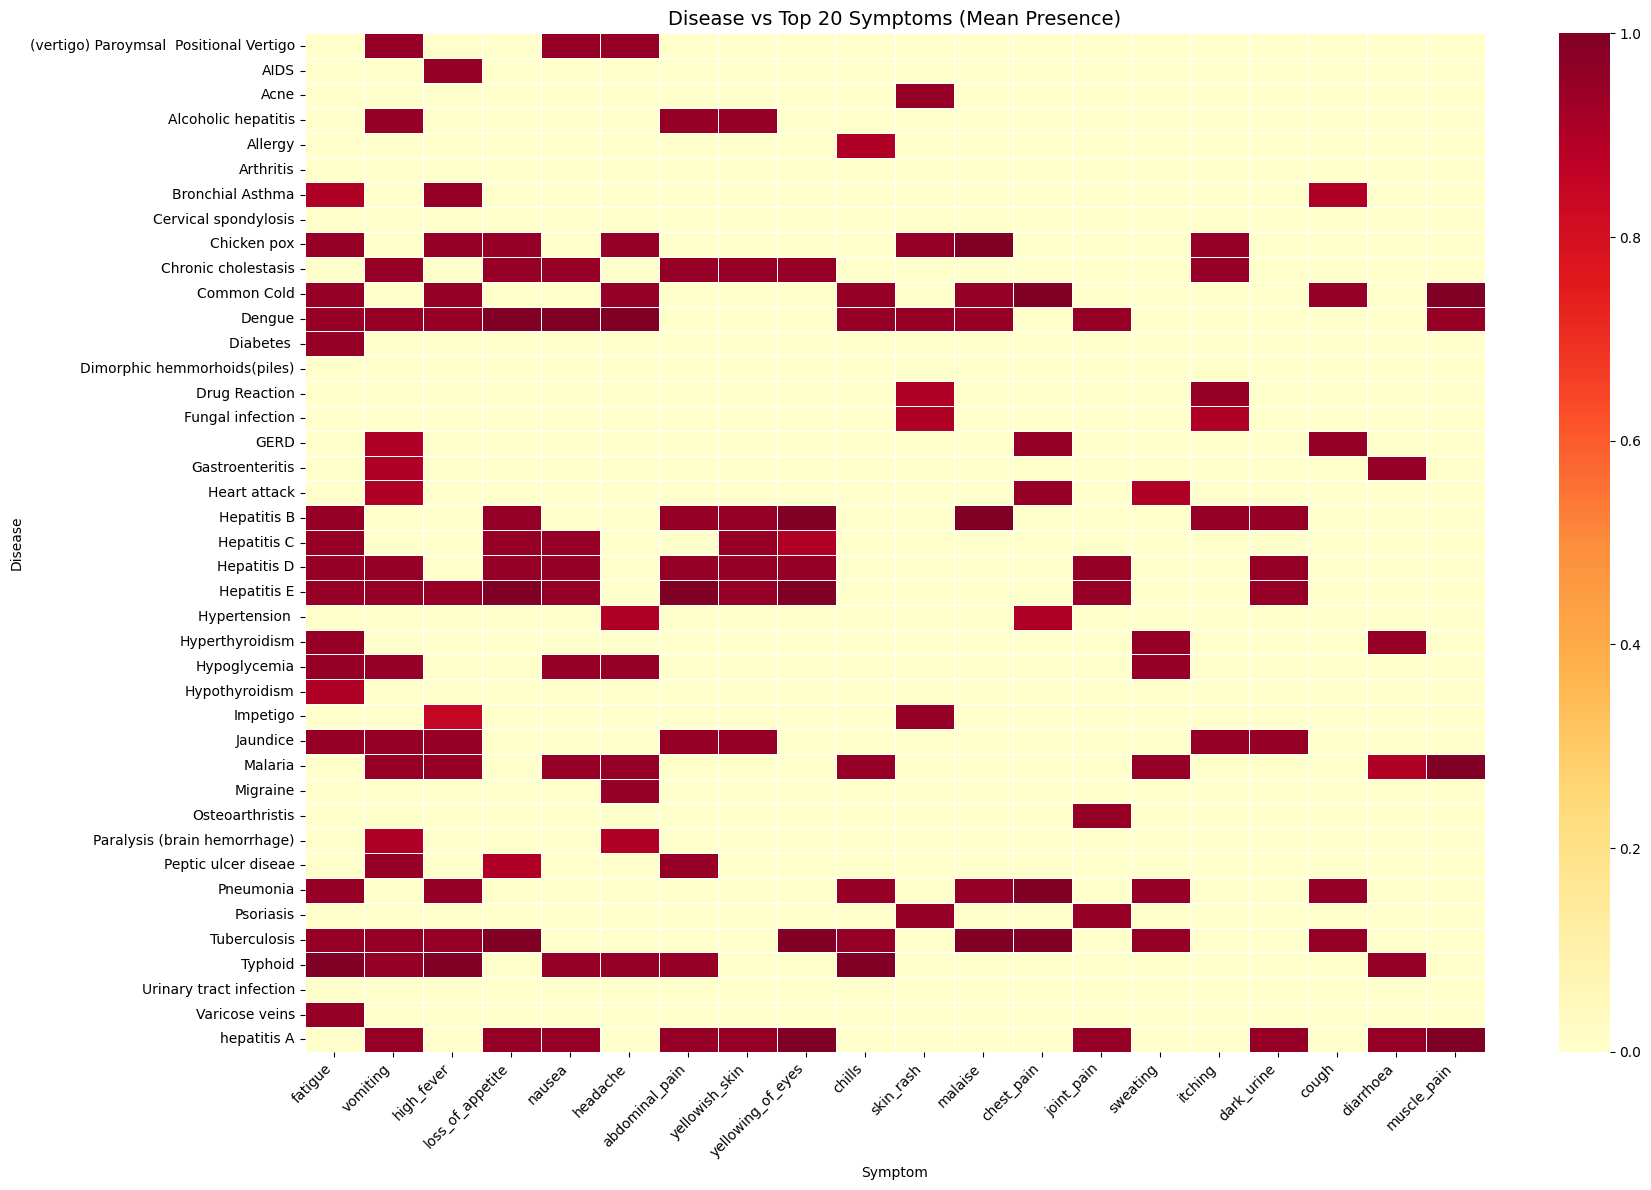

In [19]:
top_20_symptoms = X_train.sum().sort_values(ascending=False).head(20).index.tolist()

heatmap_data = train_copy.groupby('prognosis')[top_20_symptoms].mean()

plt.figure(figsize=(18, 12))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.5, annot=False)
plt.title('Disease vs Top 20 Symptoms (Mean Presence)', fontsize=14)
plt.xlabel('Symptom')
plt.ylabel('Disease')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Train All Three Models

In [21]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Bernoulli NB": BernoulliNB()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} - training done")

Decision Tree - training done
Random Forest - training done
Bernoulli NB - training done


# Accuracy Comparison

In [23]:
print(f"{'Model':<20} {'Accuracy':>10}")
print("-" * 32)

for name, model in models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name:<20} {acc*100:>9.2f}%")

Model                  Accuracy
--------------------------------
Decision Tree            97.62%
Random Forest            97.62%
Bernoulli NB            100.00%


In [25]:
for name, model in models.items():
    preds = model.predict(X_test)
    print(f"\n{'='*55}")
    print(f"  Classification Report — {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, preds, target_names=le.classes_))


  Classification Report — Decision Tree
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00      1.00      1

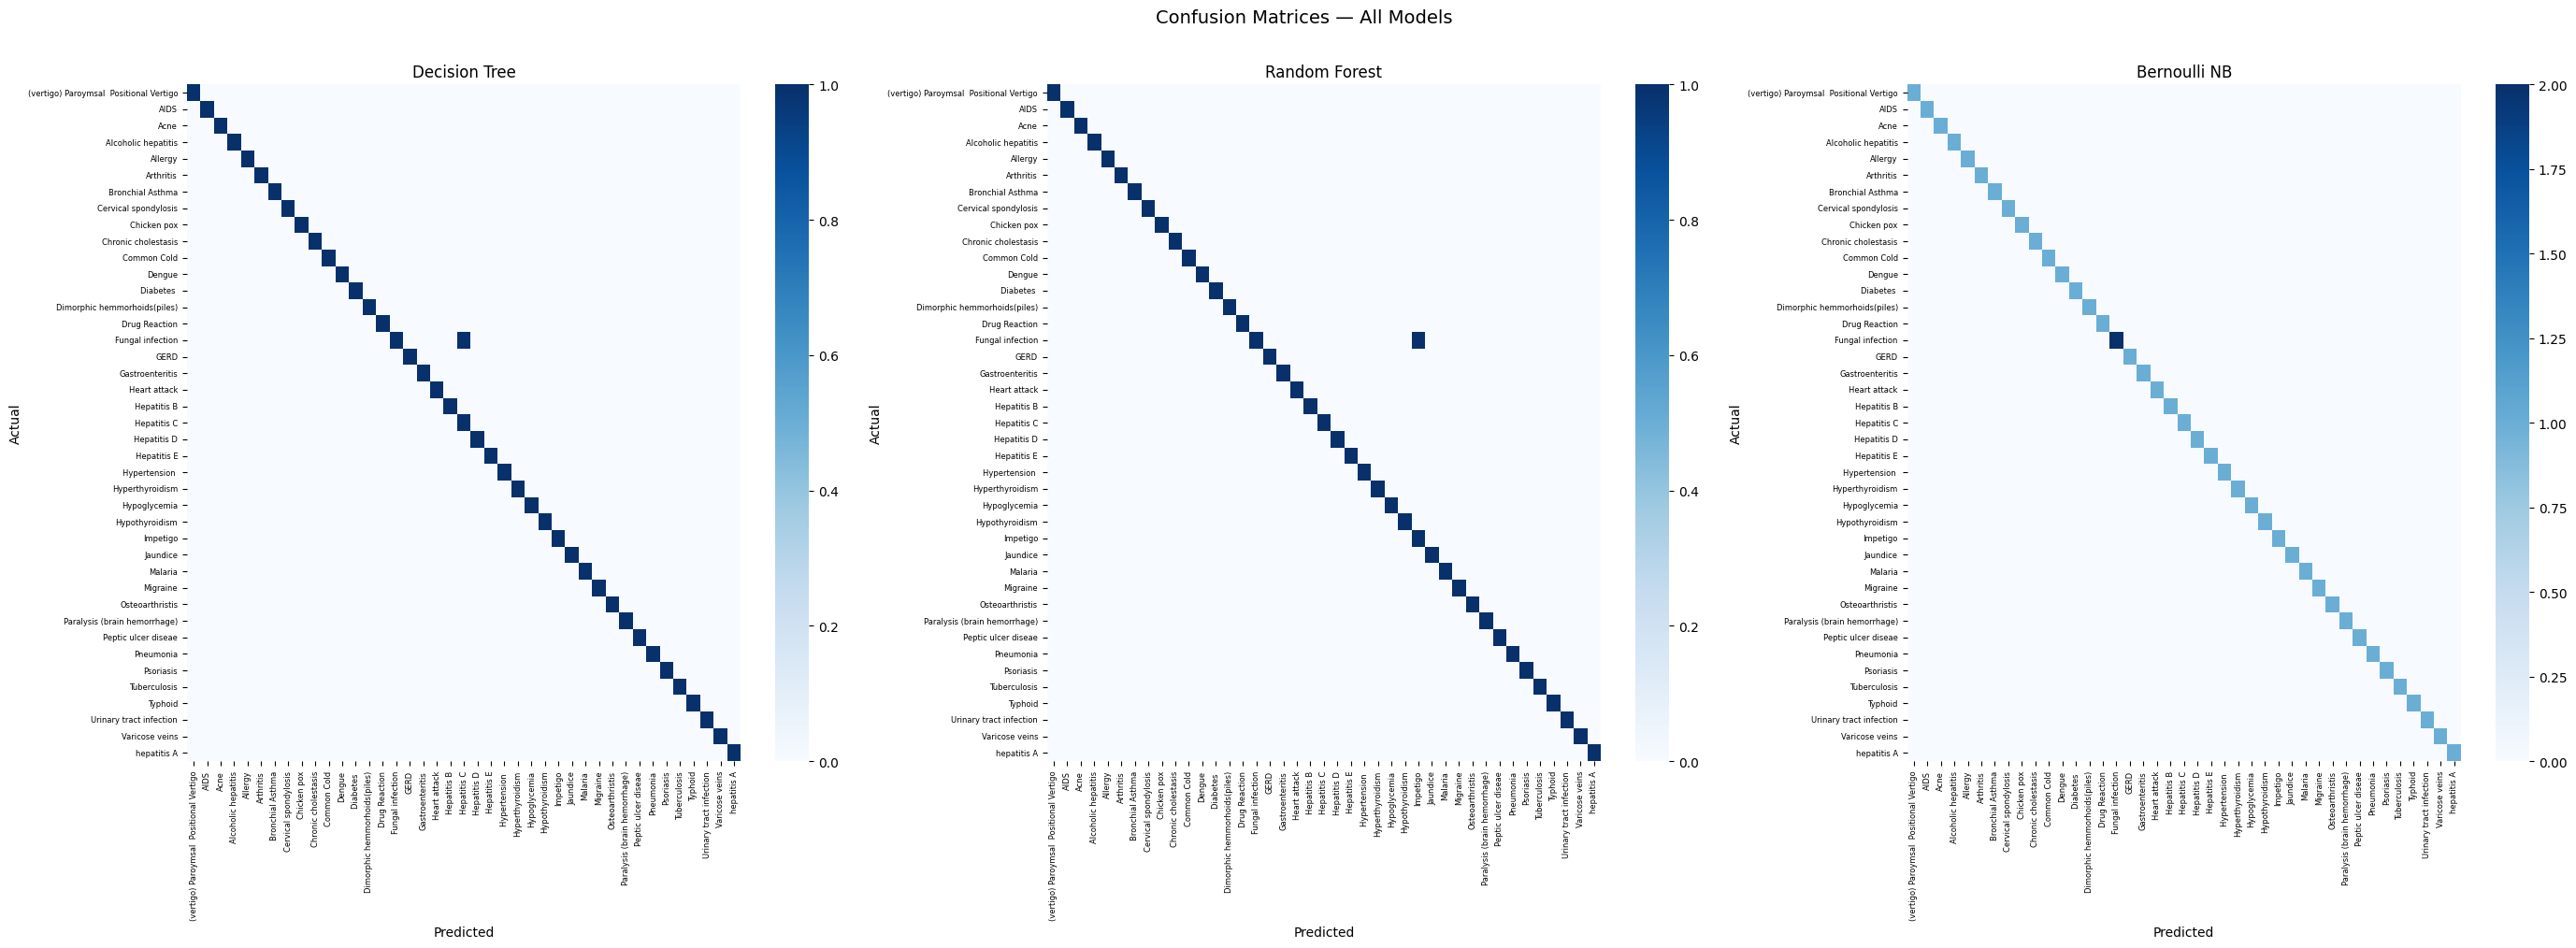

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(28, 10))

for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=False, cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(f'{name}', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=90, labelsize=6)
    ax.tick_params(axis='y', rotation=0, labelsize=6)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

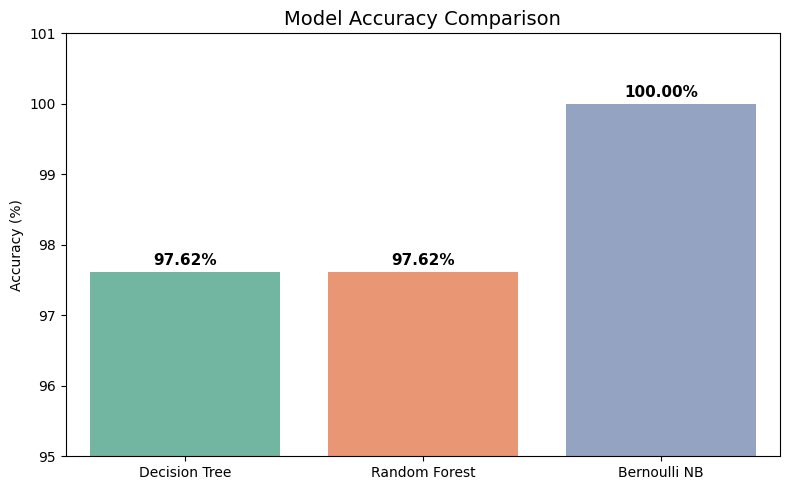

In [29]:
model_names = list(models.keys())
accuracies = [accuracy_score(y_test, models[name].predict(X_test)) * 100 for name in model_names]

plt.figure(figsize=(8, 5))
bars = sns.barplot(x=model_names, y=accuracies, palette='Set2')
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(95, 101)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.1, f"{v:.2f}%", ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()